In [20]:
import pylab
from matplotlib import gridspec
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import numpy as np
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets
import pickle
import os
import gzip


In [21]:
np.random.seed(1)
import random

In [22]:
help(make_classification)

Help on function make_classification in module sklearn.datasets._samples_generator:

make_classification(n_samples=100, n_features=20, *, n_informative=2, n_redundant=2, n_repeated=0, n_classes=2, n_clusters_per_class=2, weights=None, flip_y=0.01, class_sep=1.0, hypercube=True, shift=0.0, scale=1.0, shuffle=True, random_state=None, return_X_y=True)
    Generate a random n-class classification problem.
    
    This initially creates clusters of points normally distributed (std=1)
    about vertices of an ``n_informative``-dimensional hypercube with sides of
    length ``2*class_sep`` and assigns an equal number of clusters to each
    class. It introduces interdependence between these features and adds
    various types of further noise to the data.
    
    Without shuffling, ``X`` horizontally stacks features in the following
    order: the primary ``n_informative`` features, followed by ``n_redundant``
    linear combinations of the informative features, followed by ``n_repeated``
 

In [23]:
n = 50
X, Y = make_classification(
    n_samples = n,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    flip_y=0
)

Y = Y*2-1 
X = X.astype(np.float32); Y = Y.astype(np.int32) # Sparer minne

# train_x, test_x, train_labels, test_labels = train_test_split(
#     X, Y, test_size=0.2, random_state=1, stratify=Y
# )


train_x, test_x = np.split(X, [ n*8//10])
train_labels, test_labels = np.split(Y, [n*8//10])

print("Features:\n",train_x[0:4])
print("Labels:\n",train_labels[0:4])

Features:
 [[-1.7441838  -1.3952037 ]
 [ 2.5921783  -0.08124504]
 [ 0.9218062   0.91789985]
 [-0.8437018  -0.18738253]]
Labels:
 [-1 -1  1 -1]


C:\Users\jsand\AppData\Local\Temp\ipykernel_14608\2456380072.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


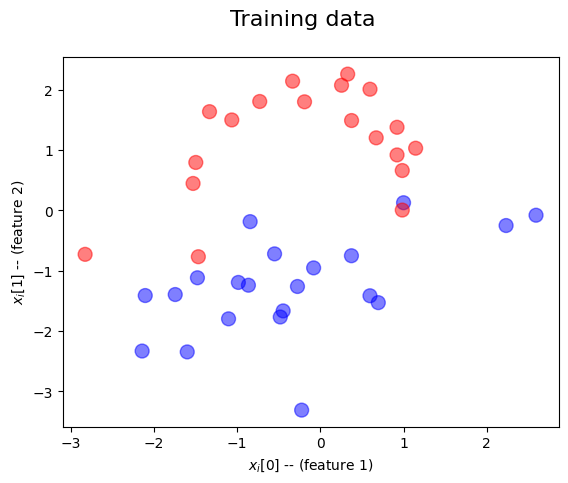

In [24]:
def plot_dataset(suptitle, features, labels):
    # prepare the plot
    fig, ax = pylab.subplots(1, 1)
    #pylab.subplots_adjust(bottom=0.2, wspace=0.4)
    fig.suptitle(suptitle, fontsize = 16)
    ax.set_xlabel('$x_i[0]$ -- (feature 1)')
    ax.set_ylabel('$x_i[1]$ -- (feature 2)')

    colors = ['r' if l>0 else 'b' for l in labels]
    ax.scatter(features[:, 0], features[:, 1], marker='o', c=colors, s=100, alpha = 0.5)
    fig.show()

plot_dataset('Training data', train_x, train_labels)

In [25]:
import numpy as np

unique, counts = np.unique(train_labels, return_counts=True)
print("Trening - klassefordeling:", dict(zip(unique, counts)))

unique, counts = np.unique(test_labels, return_counts=True)
print("Test - klassefordeling:", dict(zip(unique, counts)))

Trening - klassefordeling: {-1: 21, 1: 19}
Test - klassefordeling: {-1: 4, 1: 6}


In [26]:
pos_examples = np.array([ [t[0], t[1], 1] for i,t in enumerate(train_x) 
                          if train_labels[i]>0])
neg_examples = np.array([ [t[0], t[1], 1] for i,t in enumerate(train_x) 
                          if train_labels[i]<0])
print(pos_examples[0:3])

[[ 0.92180622  0.91789985  1.        ]
 [-1.06435513  1.49764717  1.        ]
 [ 0.32839951  2.25677919  1.        ]]


In [27]:
def train(positive_examples, negative_examples, num_iterations = 100, learning_rate = 0.01):
    num_dims = positive_examples.shape[1]
    
    # Initialize weights. 
    # We initialize with 0 for simplicity, but random initialization is also a good idea
    weights = np.zeros((num_dims,1)) 
    
    pos_count = positive_examples.shape[0]
    neg_count = negative_examples.shape[0]
    
    report_frequency = 10
    
    for i in range(num_iterations):
        # Pick one positive and one negative example
        idx = np.random.randint(len(positive_examples))
        pos = positive_examples[idx]
        neg = negative_examples[np.random.randint(len(negative_examples))]

        z = np.dot(pos, weights)   
        if z < 0: # positive example was classified as negative
            weights = weights + learning_rate * pos.reshape(weights.shape)

        z  = np.dot(neg, weights)
        if z >= 0: # negative example was classified as positive
            weights = weights - learning_rate * neg.reshape(weights.shape)
            
        # Periodically, print out the current accuracy on all examples 
        if i % report_frequency == 0:             
            pos_out = np.dot(positive_examples, weights)
            neg_out = np.dot(negative_examples, weights)        
            pos_correct = (pos_out >= 0).sum() / float(pos_count)
            neg_correct = (neg_out < 0).sum() / float(neg_count)
            print("Iteration={}, pos correct={}, neg correct={}".format(i,pos_correct,neg_correct))

    return weights


In [28]:
wts = train(pos_examples,neg_examples)
print(wts.transpose())

Iteration=0, pos correct=0.631578947368421, neg correct=0.8571428571428571
Iteration=10, pos correct=0.8421052631578947, neg correct=0.9523809523809523
Iteration=20, pos correct=0.7894736842105263, neg correct=1.0
Iteration=30, pos correct=0.7894736842105263, neg correct=0.8571428571428571
Iteration=40, pos correct=0.7368421052631579, neg correct=1.0
Iteration=50, pos correct=0.8947368421052632, neg correct=0.9047619047619048
Iteration=60, pos correct=0.9473684210526315, neg correct=0.9523809523809523
Iteration=70, pos correct=0.8947368421052632, neg correct=1.0
Iteration=80, pos correct=0.9473684210526315, neg correct=0.9523809523809523
Iteration=90, pos correct=1.0, neg correct=0.9047619047619048
[[-0.01134276  0.03823711  0.        ]]


In [29]:
def plot_boundary(positive_examples, negative_examples, weights):
    if np.isclose(weights[1], 0):
        if np.isclose(weights[0], 0):
            x = y = np.array([-6, 6], dtype = 'float32')
        else:
            y = np.array([-6, 6], dtype='float32')
            x = -(weights[1] * y + weights[2])/weights[0]
    else:
        x = np.array([-6, 6], dtype='float32')
        y = -(weights[0] * x + weights[2])/weights[1]

    pylab.xlim(-6, 6)
    pylab.ylim(-6, 6)                      
    pylab.plot(positive_examples[:,0], positive_examples[:,1], 'bo')
    pylab.plot(negative_examples[:,0], negative_examples[:,1], 'ro')
    pylab.plot(x, y, 'g', linewidth=2.0)
    pylab.show()

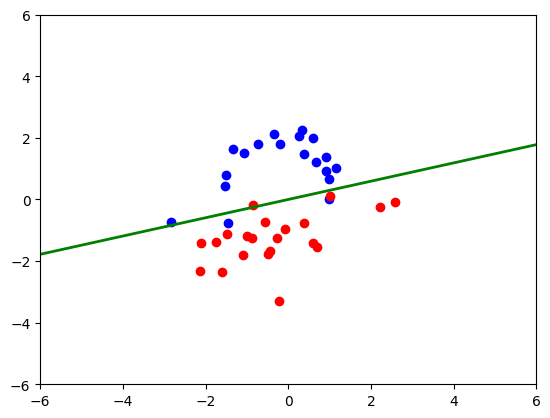

In [30]:
plot_boundary(pos_examples,neg_examples,wts)

Iteration=0, pos correct=0.7894736842105263, neg correct=0.8571428571428571
Iteration=10, pos correct=0.8947368421052632, neg correct=0.9523809523809523
Iteration=20, pos correct=0.8947368421052632, neg correct=0.9523809523809523
Iteration=30, pos correct=0.7894736842105263, neg correct=1.0
Iteration=40, pos correct=0.7894736842105263, neg correct=1.0
Iteration=50, pos correct=0.8947368421052632, neg correct=0.9047619047619048
Iteration=60, pos correct=0.9473684210526315, neg correct=0.9523809523809523
Iteration=70, pos correct=0.8947368421052632, neg correct=0.6666666666666666
Iteration=80, pos correct=0.8947368421052632, neg correct=0.9523809523809523
Iteration=90, pos correct=0.8947368421052632, neg correct=0.9523809523809523
Iteration=0, pos correct=0.6842105263157895, neg correct=0.8571428571428571
Iteration=10, pos correct=0.7894736842105263, neg correct=1.0
Iteration=20, pos correct=0.7894736842105263, neg correct=1.0
Iteration=30, pos correct=1.0, neg correct=0.6190476190476191

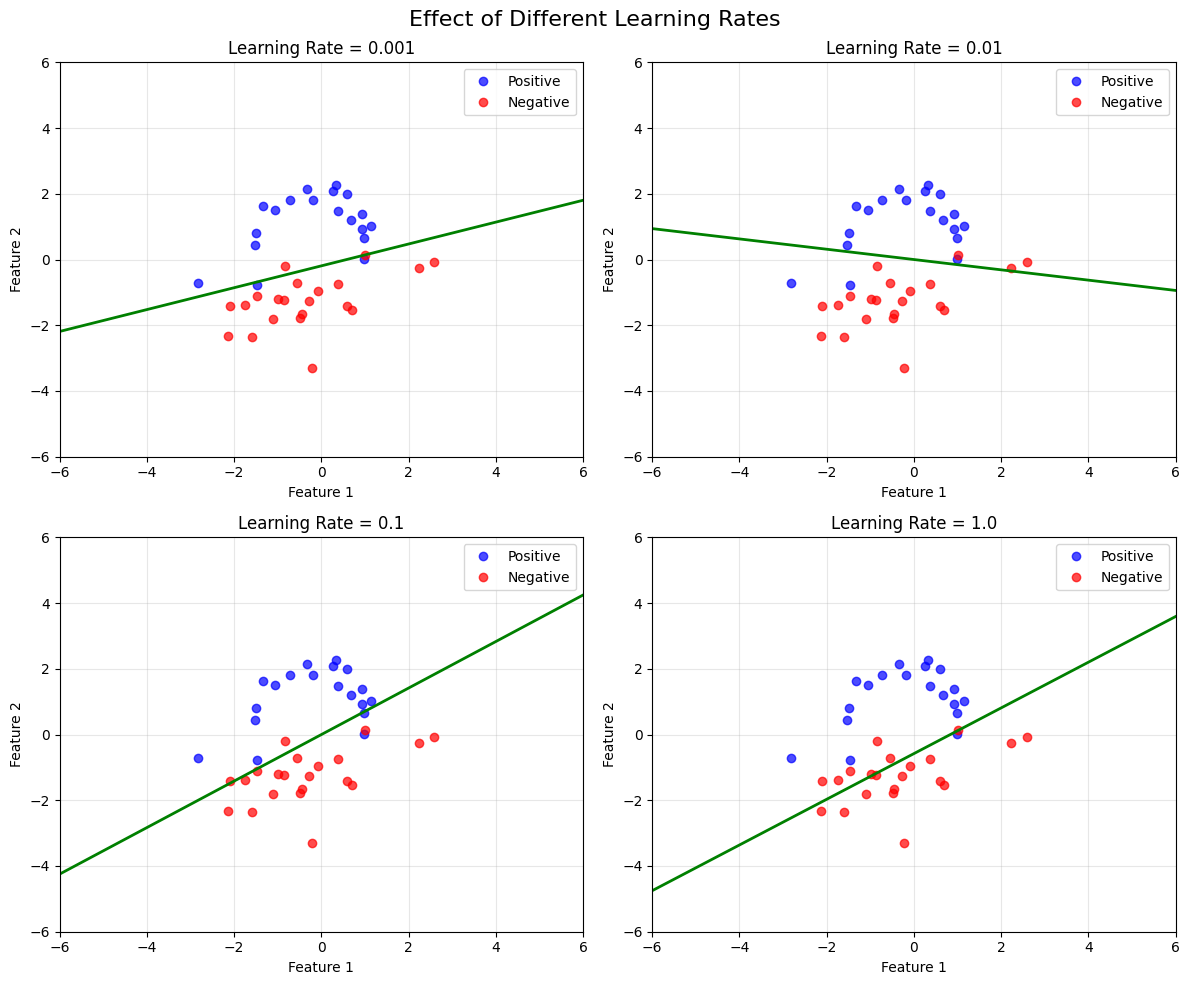

In [31]:
learning_rates = [0.001, 0.01, 0.1, 1.0]
fig, axes = pylab.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Effect of Different Learning Rates', fontsize=16)

for idx, lr in enumerate(learning_rates):
    ax = axes[idx // 2, idx % 2]
    
    # Train with this learning rate
    weights_lr = train(pos_examples, neg_examples, num_iterations=100, learning_rate=lr)
    
    # Plot decision boundary
    if np.isclose(weights_lr[1], 0):
        if np.isclose(weights_lr[0], 0):
            x = y = np.array([-6, 6], dtype='float32')
        else:
            y = np.array([-6, 6], dtype='float32')
            x = -(weights_lr[1] * y + weights_lr[2])/weights_lr[0]
    else:
        x = np.array([-6, 6], dtype='float32')
        y = -(weights_lr[0] * x + weights_lr[2])/weights_lr[1]
    
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.plot(pos_examples[:, 0], pos_examples[:, 1], 'bo', label='Positive', alpha=0.7)
    ax.plot(neg_examples[:, 0], neg_examples[:, 1], 'ro', label='Negative', alpha=0.7)
    ax.plot(x, y, 'g-', linewidth=2)
    ax.set_title(f'Learning Rate = {lr}')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend()
    ax.grid(True, alpha=0.3)

pylab.tight_layout()
pylab.show()

In [33]:
def accuracy(weights, test_x, test_labels):
    res = np.dot(np.c_[test_x,np.ones(len(test_x))],weights)
    return (res.reshape(test_labels.shape)*test_labels>=0).sum()/float(len(test_labels))

accuracy(wts, test_x, test_labels)

1.0